In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, init_weights
from src.utils import lyapunov_autograd, train

In [3]:
from matplotlib.colors import LinearSegmentedColormap

tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground",
    [
        "#f4a261", # orange
        "#ffffff", # white
        "#2a9df4"  # blue
    ]
)

In [4]:
data = np.load("xor_dataset_n0p1.npz")

X_train = data["X"]
y_train = data["y"]
# epsilon = data["epsilon"]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [5]:
data = np.load("xor_dataset_n0p1_val.npz")

X_val = data["X"]
y_val = data["y"]

X_val_standardized = (X_val - mean)/std

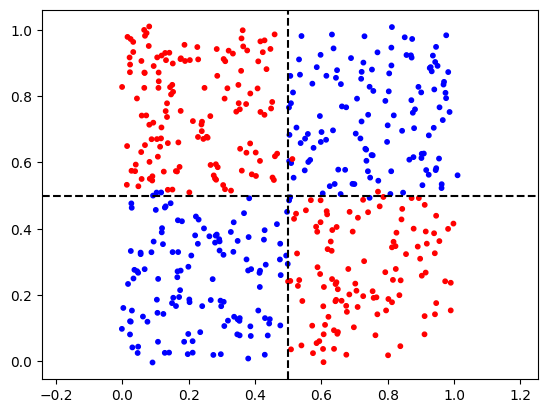

In [6]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr", s=10)
plt.axvline(0.5, color="k", linestyle="--")
plt.axhline(0.5, color="k", linestyle="--")
plt.axis("equal")
plt.show()

In [7]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32).float()
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).float()  # add dimension if needed

X_val_standardized = torch.tensor(X_val_standardized, dtype=torch.float32).float()
y_val = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_standardized, y_train)
val_ds = TensorDataset(X_val_standardized, y_val)

train_dataloader = DataLoader(train_ds, batch_size=64)
val_dataloader = DataLoader(val_ds, batch_size=64)

In [8]:
M = 10
seeds = [42]
# seeds = [11]

radii = np.linspace(0.2, 1.8, 40)
loss_fn = nn.MSELoss()

In [9]:
def point_generator(radius, n=32):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

In [10]:
T = 1.0
all_LEs = []
all_LEs_min = []
for seed in seeds:
    torch.manual_seed(seed)

    neural_ode = NeuralODEClassifier(input_dim=2, hidden_dim=3)
    neural_ode.apply(lambda m: init_weights(m, init_type="orthogonal", gain=0.9))

    train(neural_ode, train_dataloader, val_dataloader, loss_fn, acc_target=0.9, seed=seed)

    run_LEs = []
    run_LEs_min = []

    neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

#     for r in radii:
#         X = point_generator(r, n=32)
#         X = torch.tensor(X, dtype=torch.float32)

#         le_r, le_rmin = lyapunov_autograd(X[0, :], X[1, :], neural_ode_trunc, mean, std, T=T)

#         run_LEs.append(le_r.mean())
#         run_LEs_min.append(le_rmin.mean())

#     all_LEs.append(run_LEs)
#     all_LEs_min.append(run_LEs_min)

# all_LEs = np.array(all_LEs)
# all_LEs_min = np.array(all_LEs_min) 

Epoch 0 | Train Loss 2.344430 | Validation Accuracy 0.344000
Epoch 20 | Train Loss 1.001096 | Validation Accuracy 0.000000
Epoch 40 | Train Loss 0.866360 | Validation Accuracy 0.000000
Epoch 60 | Train Loss 0.456413 | Validation Accuracy 0.608000
Epoch 80 | Train Loss 0.442561 | Validation Accuracy 0.648000
Epoch 100 | Train Loss 0.438625 | Validation Accuracy 0.644000
Epoch 120 | Train Loss 0.434723 | Validation Accuracy 0.652000
Epoch 140 | Train Loss 0.430289 | Validation Accuracy 0.652000
Epoch 160 | Train Loss 0.424717 | Validation Accuracy 0.656000
Epoch 180 | Train Loss 0.416910 | Validation Accuracy 0.664000
Epoch 200 | Train Loss 0.404365 | Validation Accuracy 0.672000
Epoch 220 | Train Loss 0.382448 | Validation Accuracy 0.692000
Epoch 240 | Train Loss 0.348041 | Validation Accuracy 0.704000
Epoch 260 | Train Loss 0.304689 | Validation Accuracy 0.728000
Epoch 280 | Train Loss 0.254362 | Validation Accuracy 0.752000
Epoch 300 | Train Loss 0.213893 | Validation Accuracy 0.76800

In [11]:
# all_LEs = np.where(np.isfinite(all_LEs), all_LEs, np.nan)
# mean_le = np.nanmean(all_LEs, axis=0)
# std_le = np.nanstd(all_LEs, axis=0)

# plt.plot(radii, mean_le, label="Mean FTLE")
# plt.fill_between(radii, mean_le-std_le, mean_le+std_le, alpha=0.3)
# plt.axhline(0, linestyle="--", color="black")
# plt.axvline(1.0, linestyle=":", color="red", label="Boundary")
# plt.legend()
# plt.xlabel("Radius")
# plt.ylabel("Largest Lyapunov Exponent")

In [12]:
# all_LEs_min = np.where(np.isfinite(all_LEs_min), all_LEs_min, np.nan)
# mean_le_min = np.nanmean(all_LEs_min, axis=0)
# std_le_min = np.nanstd(all_LEs_min, axis=0)

# plt.plot(radii, mean_le_min, label="Mean FTLE")
# plt.fill_between(radii, mean_le_min-std_le_min, mean_le_min+std_le_min, alpha=0.3)
# plt.axhline(0, linestyle="--", color="black")
# plt.axvline(1.0, linestyle=":", color="red", label="Boundary")
# plt.legend()
# plt.xlabel("Radius")
# plt.ylabel("Smallest FT Lyapunov Exponent")

In [13]:
x_vals = np.linspace(0, 1, 100)
y_vals = np.linspace(0, 1, 100)

t0 = 0.0
t1 = 1.0

In [14]:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))
lyap_grid_min = np.zeros_like(lyap_grid)

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)

        # Singular values
        svals = torch.linalg.svdvals(J)

        # Largest Lyapunov proxy
        lyap_grid[j, i] = (1.0/T) * torch.log(svals.max()).item()
        lyap_grid_min[j, i] =(1.0/T) * torch.log(svals.min()).item()

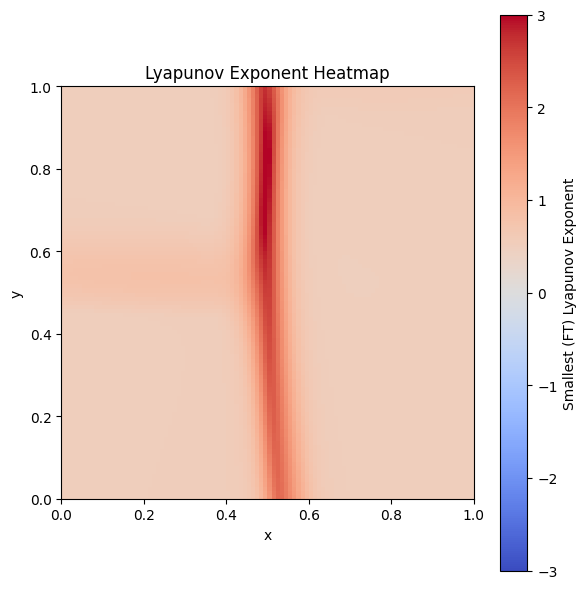

In [15]:
plt.figure(figsize=(6,6))
plt.imshow(
    lyap_grid,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',        # or 'viridis', 'plasma', etc.
    vmin=-3,
    vmax=3
)
plt.colorbar(label="Smallest (FT) Lyapunov Exponent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Lyapunov Exponent Heatmap")
plt.tight_layout()
plt.show()

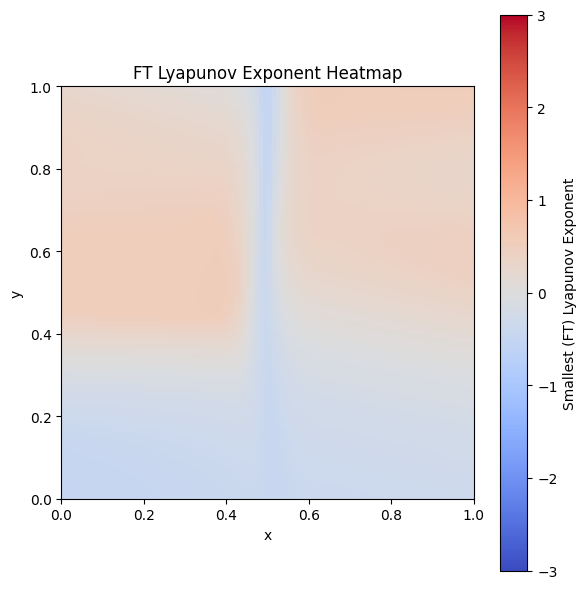

In [16]:
plt.figure(figsize=(6,6))
plt.imshow(
    lyap_grid_min,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',        # or 'viridis', 'plasma', etc.
    vmin=-3,
    vmax=3
)
plt.colorbar(label="Smallest (FT) Lyapunov Exponent")
plt.xlabel("x")
plt.ylabel("y")
plt.title("FT Lyapunov Exponent Heatmap")
plt.tight_layout()
plt.show()

In [17]:
X, Y = np.meshgrid(x_vals, y_vals)

points = np.stack([X.ravel(), Y.ravel()], axis=1)
points_t = torch.tensor(points, dtype=torch.float32)

points_t = ((points_t - mean) / std).float()

neural_ode.eval()
with torch.no_grad():
    preds = neural_ode(points_t).cpu().numpy()

Z = preds.reshape(len(x_vals), len(y_vals))

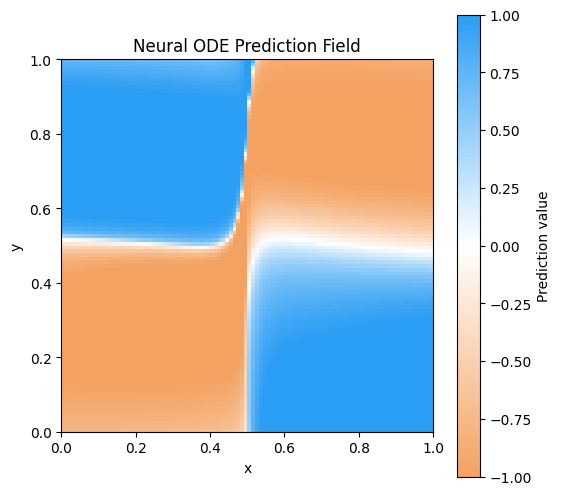

In [18]:
plt.figure(figsize=(6,6))
plt.imshow(
    Z,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap=tf_playground,
    vmin=-1,
    vmax=1
)
plt.colorbar(label="Prediction value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural ODE Prediction Field")
plt.show()


In [19]:
t_eval = torch.linspace(0, 1, 60)

with torch.no_grad():
    traj = neural_ode.get_hidden_trajectory(points_t, t_eval) # Shape time_steps, num_points, 3

In [20]:
x_colors = points_t[:, 0]
y_colors = points_t[:, 1]

labels = torch.where((x_colors>0.5) ^ (y_colors> 0.5), -1, 1)

colors = torch.zeros((points_t.shape[0], 3)) # RGB

# Red if the point is inside the circle
colors[labels == -1] = torch.tensor([1.0, 0.0, 0.0])

# Blue if the point is outside the circle
colors[labels == 1] = torch.tensor([0.0, 0.0, 1.0])
colors_np = colors.numpy()

Saved GIF: xor_hidden_flow_42.gif


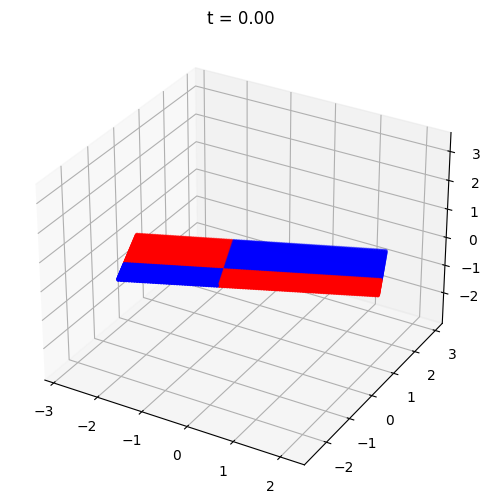

In [21]:
from matplotlib.animation import FuncAnimation
import matplotlib
# matplotlib.use("Agg")

T, N, _ = traj.shape
traj_np = traj.cpu().numpy()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Initial scatter
scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_np, s=5)

ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
# ax.set_title("Neural ODE flow in hidden space"

def update(frame):
    scatter._offsets3d = (
        traj_np[frame,:,0],
        traj_np[frame,:,1],
        traj_np[frame,:,2],
    )
    ax.set_title(f"t = {frame/(T-1):.2f}")
    return scatter,

anim = FuncAnimation(fig, update, frames=T, interval=80)

anim.save("xor_hidden_flow_42.gif", writer="pillow", fps=15)
print("Saved GIF: xor_hidden_flow_42.gif")

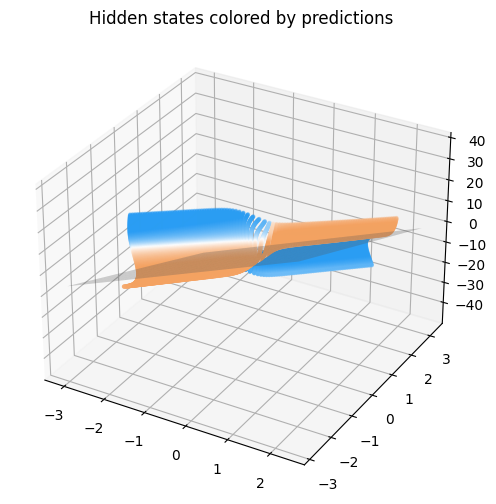

In [22]:
# Z is shape (len(x_vals), len(y_vals)), e.g., (100,100)
Z_flat = Z.ravel()  # shape (10000,)

# Normalize predictions to [0,1] if needed
Z_norm = (Z_flat + 1) / 2  # assuming predictions in [-1,1]

# Map to colors
colors_pred = tf_playground(Z_norm)  # shape (10000, 4) 
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_pred, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()


In [23]:
fig.savefig("xor_final_frame_pred_42.png")

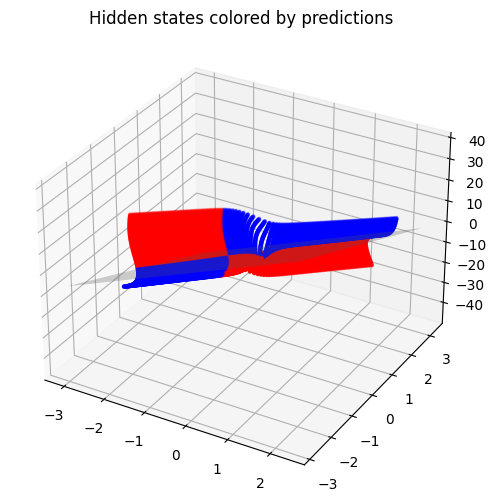

In [24]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_np, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()

In [25]:
fig.savefig("xor_final_frame_true_42.png")